# Retención de clientes y mensaje de fidelización personalizado

1. Consulta de SQL para extraer las métricas relevantes de los clientes
2. Generar datos sintéticos que simulen el comportamiento de compra de los clientes
3. Segmentar los clientes mediante ML
4. Generar mensajes de fidelización personalizados

# Consulta de SQL

SELECT 
    cliente_id,
    DATEDIFF(CURRENT_DATE, MAX(transaccion_fecha)) AS recencia,
    COUNT(transaccion_id) AS frecuencia
    SUM(monto_total) AS monto
FROM transacciones
GROUP BY cliente_id;

SELECT
    t.cliente_id,
    p.categoria,
    COUNT(*) AS monto
FROM transacciones t
JOIN productos p
    ON t.producto_id = p.producto_id
GROUP BY t.cliente_id, p.categoria
ORDER BY t.cliente_id, monto DESC

# importar las librerias

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

np.random.seed(42)

# Diseño de datos sintético

Variables:
- Customer ID: identificador del cliente
- Recencia: días desde la última compra
- Frecuencia: número total de compras
- Monto: monto total gastado
- categoria: la categoría de producto más comprada

In [5]:
cliente_id = np.arange(1, 1001)

recencia = np.random.exponential(scale=60, size=1000)
recencia = recencia.astype(int)
recencia = np.clip(recencia, 1, 365)

frecuencia = np.random.poisson(lam=6, size=1000)
frecuencia = np.clip(frecuencia, 1, None)

monto = np.random.lognormal(mean=7, sigma=1, size=1000)
monto = np.clip(monto, 10, np.percentile(monto, 99))
monto = np.round(monto, 2)

categorias = ["Construccion", "Acabados", "Puertas y ventanas", 
              "Baño y plomeria", "Cocina",
              "Herramientas", "Pintura", "Electrico", "Ferreteria",
                "Muebles y organizacion", "Autos y motos", 
                "Iluminacion y ventilacion", "TV audio electronica y celulares"]

categoria_favorita = np.random.choice(categorias, size=1000)

clientes = pd.DataFrame({"cliente_id" : cliente_id, "recencia" : recencia,
                          "frecuencia" : frecuencia, "monto_total" : monto, 
                          "categoria_favorita" : categoria_favorita})

# Validar el dataset

In [6]:
clientes.head()

,cliente_id,recencia,frecuencia,monto_total,categoria_favorita
0,1,40,4,8348.30,TV audio electronica y celulares
1,2,74,7,560.11,Construccion
2,3,121,5,610.40,Acabados
3,4,163,7,2427.60,Acabados
4,5,23,5,9067.34,Cocina


In [7]:
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          1000 non-null   int64  
 1   recencia            1000 non-null   int64  
 2   frecuencia          1000 non-null   int32  
 3   monto_total         1000 non-null   float64
 4   categoria_favorita  1000 non-null   str    
dtypes: float64(1), int32(1), int64(2), str(1)
memory usage: 35.3 KB


In [8]:
clientes.isnull().sum()

cliente_id            0
recencia              0
frecuencia            0
monto_total           0
categoria_favorita    0
dtype: int64

In [9]:
clientes.duplicated().sum()

np.int64(0)

In [10]:
clientes.describe()

,cliente_id,recencia,frecuencia,monto_total
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,60.19700,6.023000,1731.950350
std,288.819436,60.50816,2.384566,1820.326331
min,1.000000,1.00000,1.000000,49.440000
25%,250.750000,18.75000,4.000000,568.010000
50%,500.500000,41.00000,6.000000,1097.360000
75%,750.250000,81.25000,7.000000,2247.557500
max,1000.000000,365.00000,17.000000,10155.100000


# Visualización

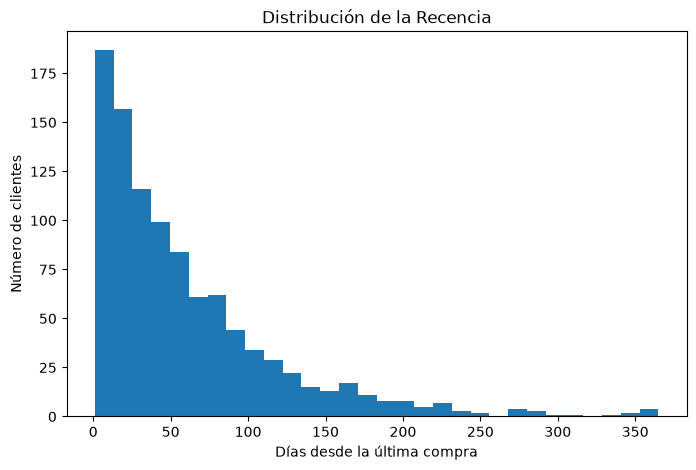

In [11]:
plt.figure(figsize=(8,5))

plt.hist(clientes["recencia"], bins=30)

plt.title("Distribución de la Recencia")
plt.xlabel("Días desde la última compra")
plt.ylabel("Número de clientes")

plt.show()

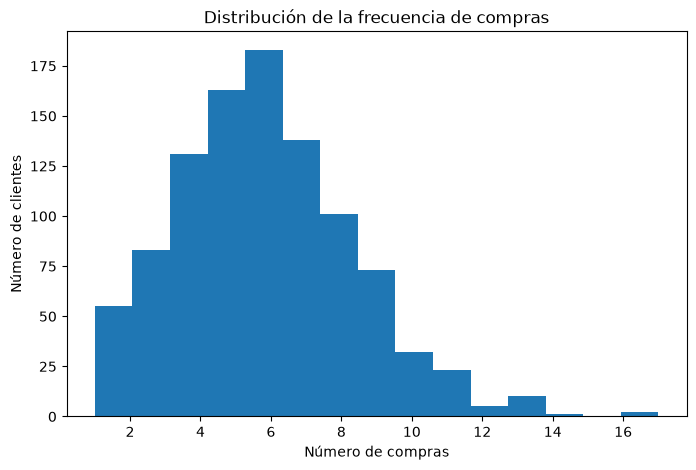

In [12]:
plt.figure(figsize=(8,5))

plt.hist(clientes["frecuencia"], bins=15)

plt.title("Distribución de la frecuencia de compras")
plt.xlabel("Número de compras")
plt.ylabel("Número de clientes")

plt.show()

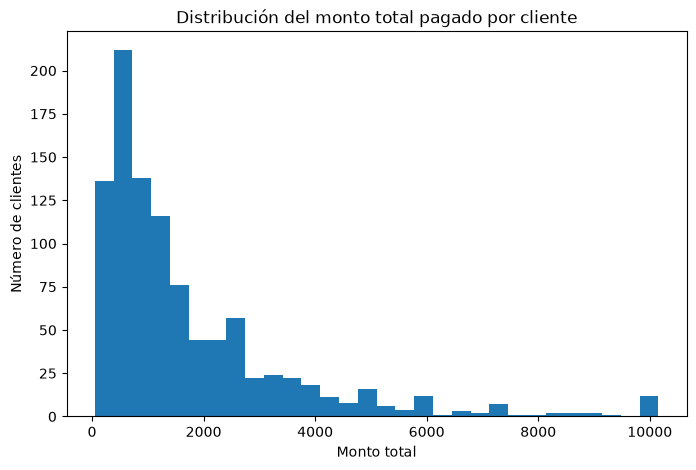

In [13]:
plt.figure(figsize=(8,5))

plt.hist(clientes["monto_total"], bins=30)

plt.title("Distribución del monto total pagado por cliente")
plt.xlabel("Monto total")
plt.ylabel("Número de clientes")

plt.show()

# Segmentacion de clientes (modelo de clustering K-Means)

In [15]:
X = clientes[
    [
        "recencia",
        "frecuencia",
        "monto_total"
    ]
]

In [16]:
X.head()

,recencia,frecuencia,monto_total
0,40,4,8348.30
1,74,7,560.11
2,121,5,610.40
3,163,7,2427.60
4,23,5,9067.34


In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Entrenamiento del modelo

In [29]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clientes["cluster"] = kmeans.fit_predict(X_scaled)

In [30]:
clientes["cluster"].value_counts()

cluster
2    715
0    163
1    122
Name: count, dtype: int64

In [32]:
clientes.groupby("cluster") [
    ["recencia", "frecuencia", "monto_total"]
].mean()

,recencia,frecuencia,monto_total
cluster,,,
0,168.128834,5.736196,1193.405890
1,50.524590,6.483607,5692.291230
2,37.241958,6.009790,1178.972951


- Cluster 1: Alto Valor (mayor monto total gastado y mayor frecuencia de compra)
- Cluster 2: Estándar (comportamiento promedio)
- Cluster 0: En Riesgo (mayor tiempo de recencia y menor monto total gastado)

In [33]:
segmentos = {0 : "En Riesgo",
             1 : "Alto Valor", 
             2 : "Estándar"}

clientes["segmento"] = clientes["cluster"].map(segmentos)

# Evaluación del modelo

In [34]:
silhouette = silhouette_score(
    X_scaled, clientes["cluster"]
)

print(f"Silhouette Score: {silhouette:.3f}")

Silhouette Score: 0.367


# Interpretacion
- Silhouette score de 0.367
- Los clusters tienen diferencias remarcables, pero hay clientes similares de diferentes segmentos